<a href="https://colab.research.google.com/github/valsson-group/UNT-ChemicalApplicationsOfMachineLearning-Spring2026/blob/main/Lecture-15_March-19-2026/Lecture_15_DimensionalityReduction_1_Solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lecture 15 - Dimensionality Reduction


Import all basic pacakges

In [1]:
# basic
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



## Two-dimensional Dataset

In [2]:
%%bash

datasets="
MuellerBrown_T-3_TimeSeries_run-1.data
MuellerBrown_T-3_TimeSeries_run-2.data
WolfeQuapp_T-1_TimeSeries_run-1.data
WolfeQuapp_T-1_TimeSeries_run-2.data
WolfeQuapp_T-2_TimeSeries_run-1.data
WolfeQuapp_T-2_TimeSeries_run-2.data
"

url="https://raw.githubusercontent.com/valsson-group/UNT-ChemicalApplicationsOfMachineLearning-Spring2026/refs/heads/main/Lecture-15_March-19-2026/Datasets"

for d in ${datasets}
do
  wget ${url}/${d} &> /dev/null
done

ls

MuellerBrown_T-3_TimeSeries_run-1.data
MuellerBrown_T-3_TimeSeries_run-2.data
sample_data
WolfeQuapp_T-1_TimeSeries_run-1.data
WolfeQuapp_T-1_TimeSeries_run-2.data
WolfeQuapp_T-2_TimeSeries_run-1.data
WolfeQuapp_T-2_TimeSeries_run-2.data


In [10]:
data = pd.read_csv("WolfeQuapp_T-1_TimeSeries_run-1.data", header=None, names=['time', 'x', 'y'], sep='\\s+', comment="#")

# only take every N-th value
stride = 10
data = data.iloc[::stride]
# this is to reset the index
data.reset_index(drop=True, inplace=True)

In [11]:
data

,time,x,y
0,0.0,-1.174000,1.477000
1,10.0,-0.876598,1.147392
2,20.0,-1.160047,1.558202
3,30.0,-1.316472,1.499633
4,40.0,-1.183654,1.204216
...,...,...,...
1996,19960.0,-0.991208,1.647111
1997,19970.0,-1.119315,1.618060
1998,19980.0,-1.821559,1.312321
1999,19990.0,-0.710136,1.195916


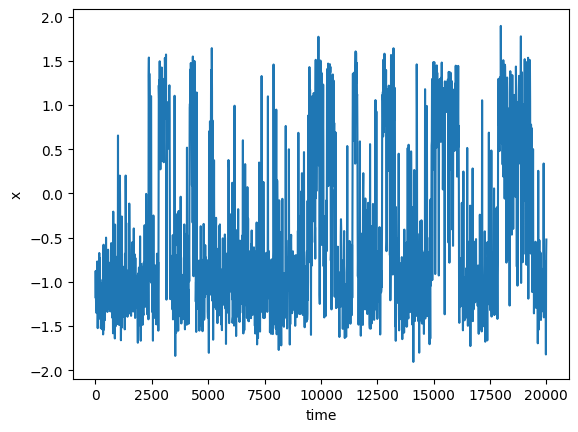

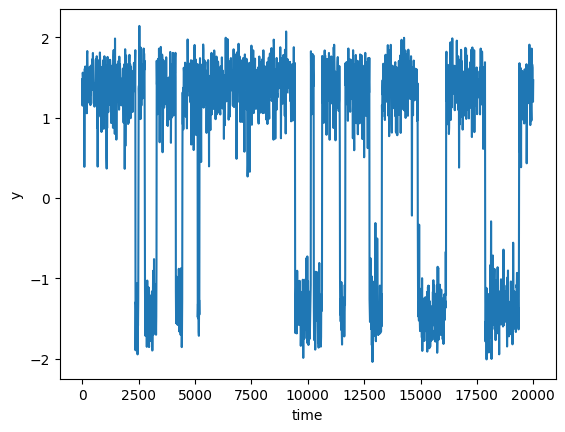

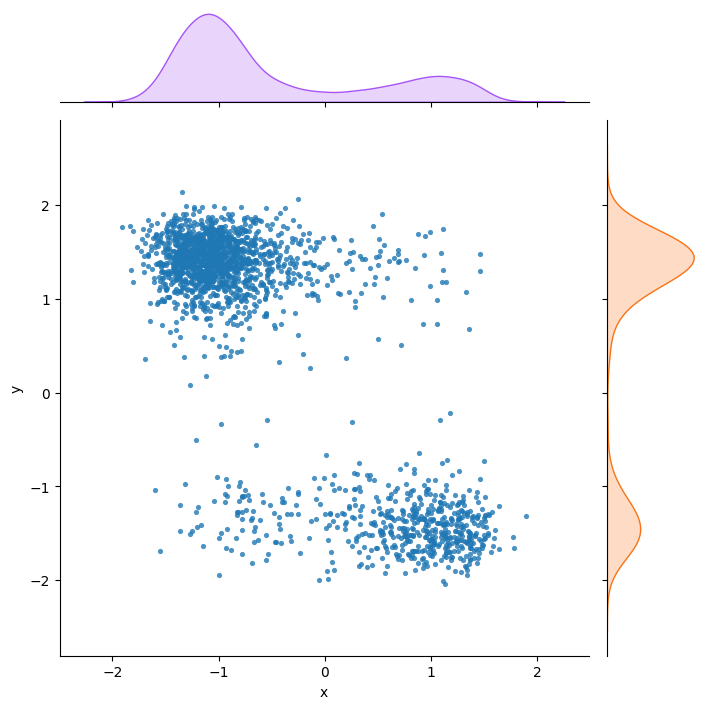

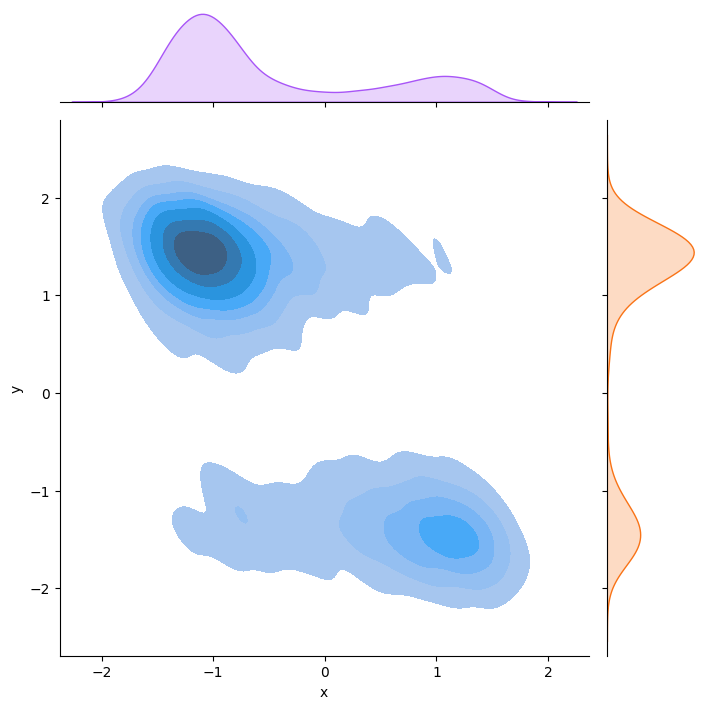

In [12]:
t=data['time']
x=data['x']
y=data['y']

plt.plot(t, x, label='x')
plt.xlabel('time')
plt.ylabel('x')
plt.show()

plt.plot(t, y, label='y')
plt.xlabel('time')
plt.ylabel('y')
plt.show()

g = sns.JointGrid(height=7, ratio=5)
ax_scatter, ax_top, ax_right = g.ax_joint, g.ax_marg_x, g.ax_marg_y
sc = ax_scatter.scatter(x, y, s=14, alpha=0.8, linewidths=0)
ax_scatter.set_xlabel("x")
ax_scatter.set_ylabel("y")
sns.kdeplot(x=x, ax=ax_top, fill=True, color="#a855f7", bw_adjust=0.6)
sns.kdeplot(y=y, ax=ax_right, fill=True, color="#f97316", bw_adjust=0.6)
plt.show()

g = sns.JointGrid(height=7, ratio=5)
ax_joint, ax_top, ax_right = g.ax_joint, g.ax_marg_x, g.ax_marg_y
sns.kdeplot(x=x, y=y,
            ax=ax_joint,
            bw_adjust=0.6,
            fill=True,
            levels=8)
ax_joint.set_xlabel("x")
ax_joint.set_ylabel("y")
sns.kdeplot(x=x, ax=ax_top, fill=True, color="#a855f7", bw_adjust=0.6)
sns.kdeplot(y=y, ax=ax_right, fill=True, color="#f97316", bw_adjust=0.6)
plt.show()



In [13]:
from sklearn.decomposition import PCA

XY = data[['x','y']]

# Apply PCA to 2D features
pca = PCA()
pca.fit(XY)

print("Explained variance ratio for 2D features:")
display(pca.explained_variance_ratio_)
print("Cumulative explained variance for 2D features:")
display(pca.explained_variance_ratio_.cumsum())

Explained variance ratio for 2D features:


array([0.91059863, 0.08940137])

Cumulative explained variance for 2D features:


array([0.91059863, 1.        ])

In [16]:
print(pca.components_[0])
print(pca.components_[1])

[-0.55179881  0.83397726]
[0.83397726 0.55179881]


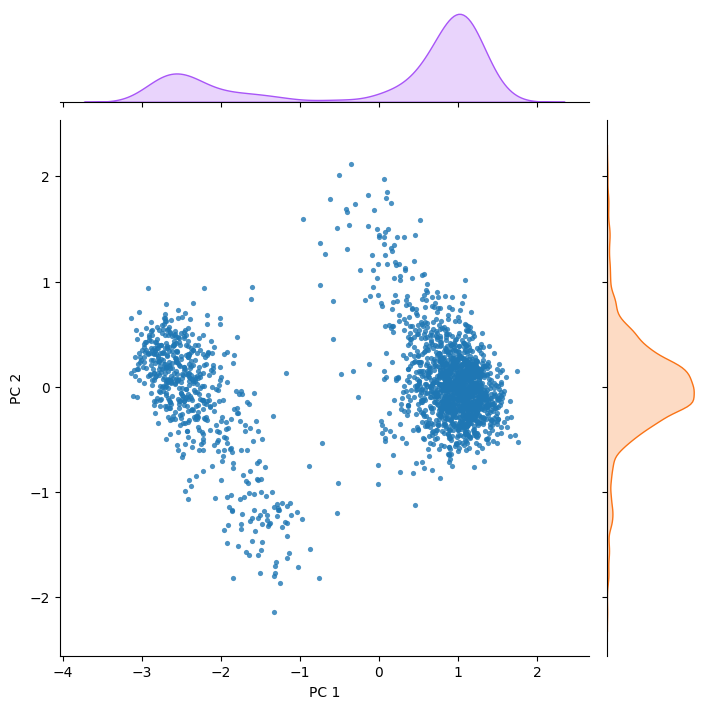

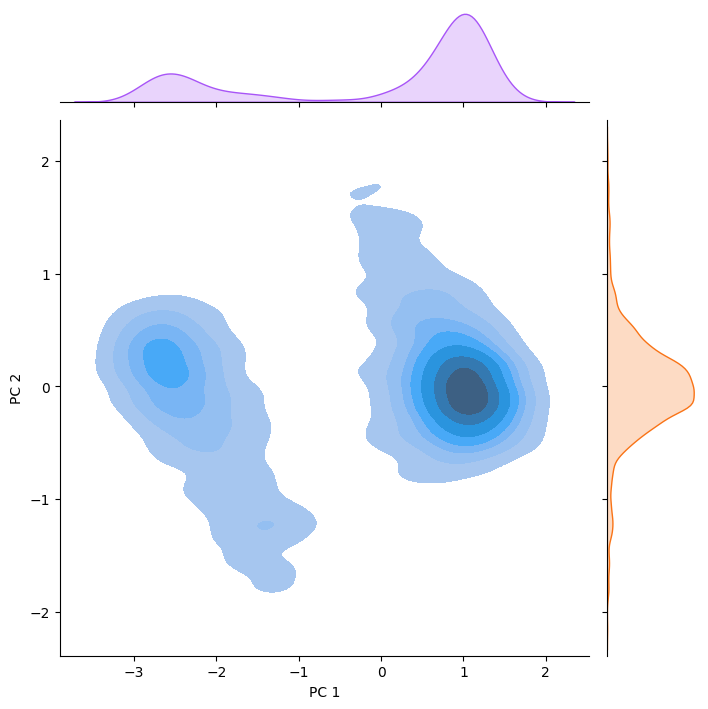

In [14]:
XY_pca = pca.transform(XY)
x=XY_pca[:,0]
y=XY_pca[:,1]

g = sns.JointGrid(height=7, ratio=5)
ax_scatter, ax_top, ax_right = g.ax_joint, g.ax_marg_x, g.ax_marg_y
sc = ax_scatter.scatter(x, y, s=14, alpha=0.8, linewidths=0)
ax_scatter.set_xlabel("PC 1")
ax_scatter.set_ylabel("PC 2")
sns.kdeplot(x=x, ax=ax_top, fill=True, color="#a855f7", bw_adjust=0.6)
sns.kdeplot(y=y, ax=ax_right, fill=True, color="#f97316", bw_adjust=0.6)
plt.show()

g = sns.JointGrid(height=7, ratio=5)
ax_joint, ax_top, ax_right = g.ax_joint, g.ax_marg_x, g.ax_marg_y
sns.kdeplot(x=x, y=y,
            ax=ax_joint,
            bw_adjust=0.6,
            fill=True,
            levels=8)
ax_joint.set_xlabel("PC 1")
ax_joint.set_ylabel("PC 2")
sns.kdeplot(x=x, ax=ax_top, fill=True, color="#a855f7", bw_adjust=0.6)
sns.kdeplot(y=y, ax=ax_right, fill=True, color="#f97316", bw_adjust=0.6)
plt.show()


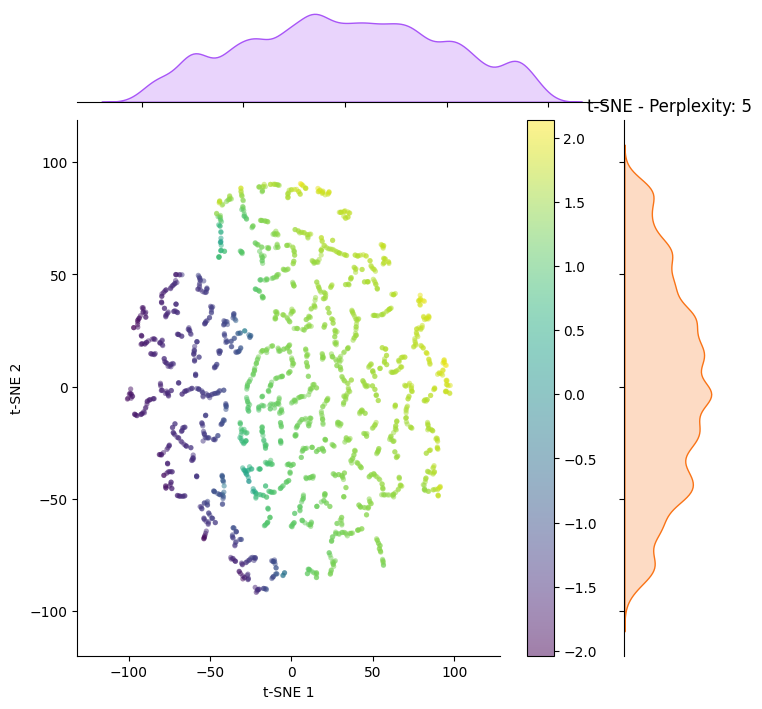

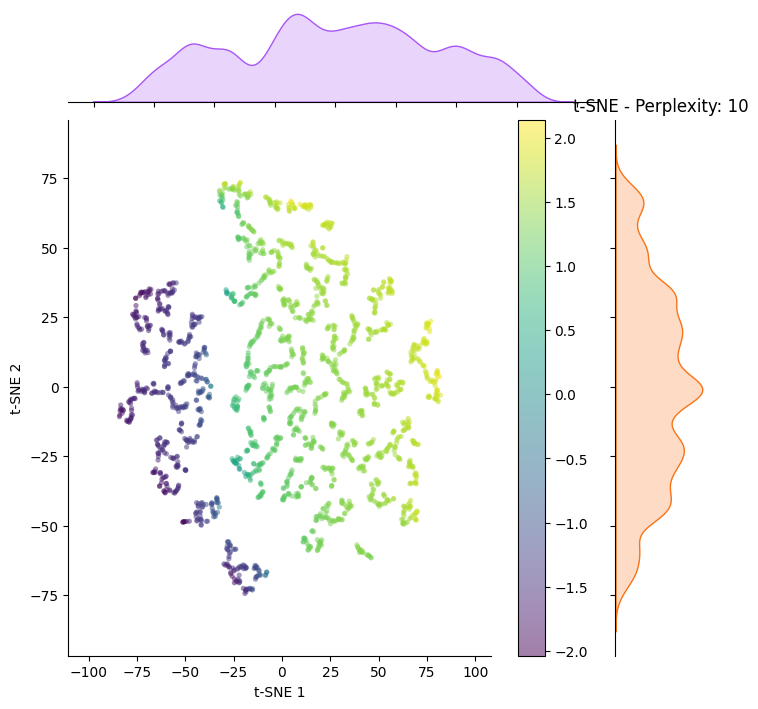

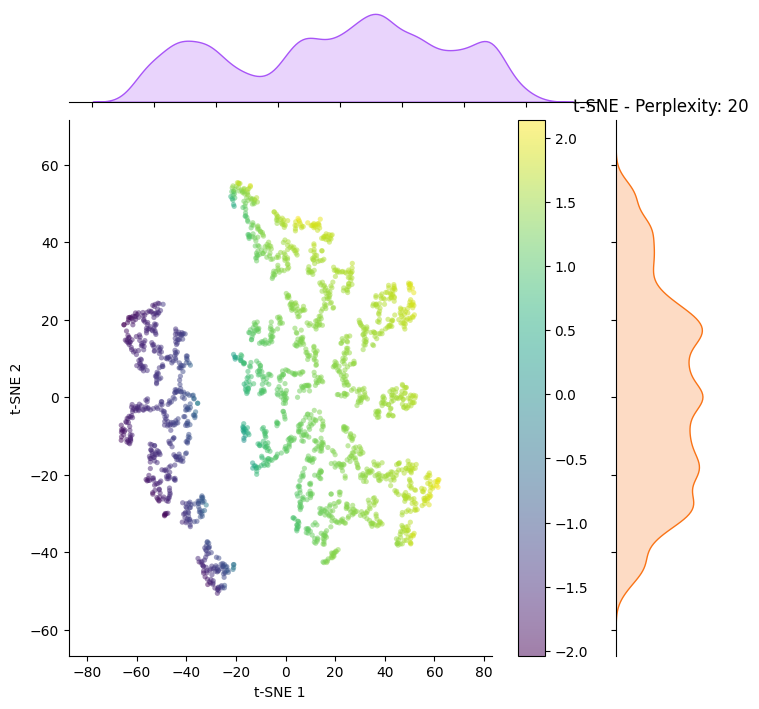

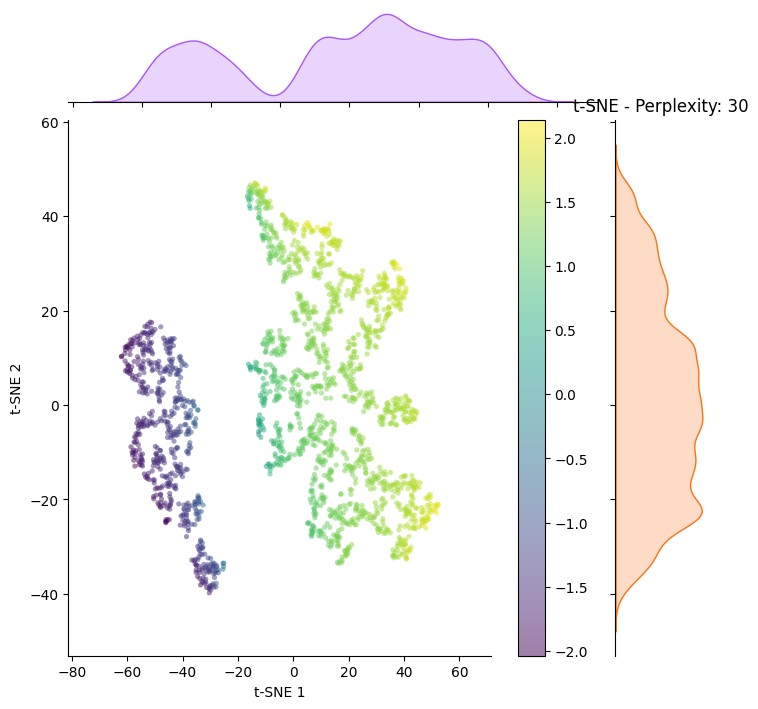

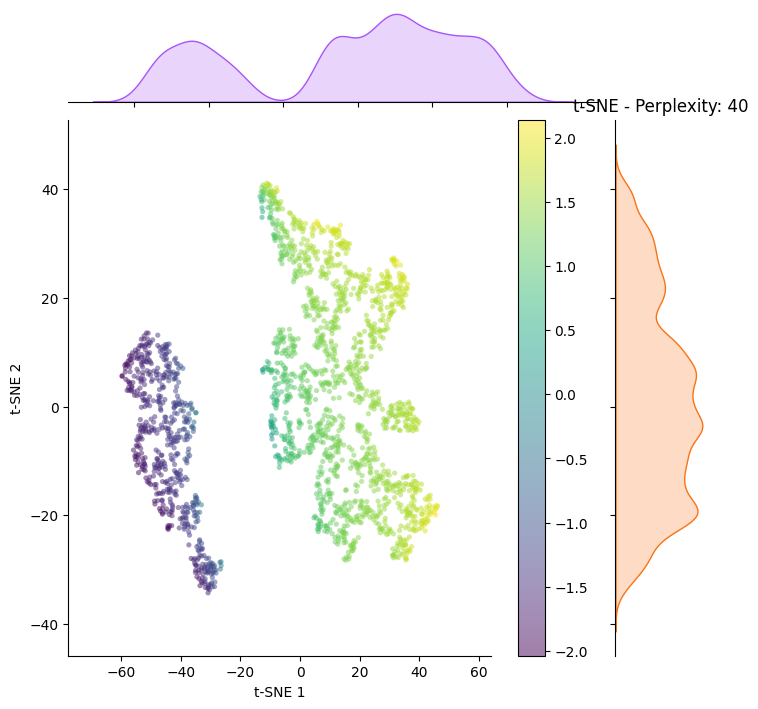

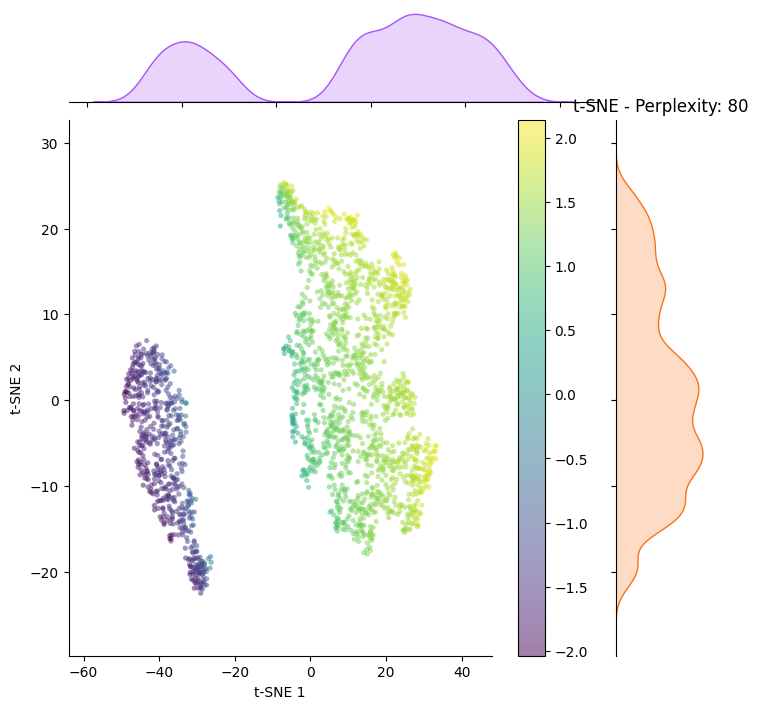

In [22]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

perplexities = [5, 10, 20, 30, 40, 80]

for perplexity in perplexities:
  tsne = TSNE(perplexity=perplexity)
  emb = tsne.fit_transform(XY)

  x = emb[:,0]
  y = emb[:,1]

  g = sns.JointGrid(height=7, ratio=5)
  ax_scatter, ax_top, ax_right = g.ax_joint, g.ax_marg_x, g.ax_marg_y
  sc = ax_scatter.scatter(x, y, c=data['y'], s=14, alpha=0.5, linewidths=0)
  ax_scatter.set_xlabel("t-SNE 1")
  ax_scatter.set_ylabel("t-SNE 2")
  g.fig.colorbar(sc, ax=ax_scatter)
  sns.kdeplot(x=x, ax=ax_top, fill=True, color="#a855f7", bw_adjust=0.6)
  sns.kdeplot(y=y, ax=ax_right, fill=True, color="#f97316", bw_adjust=0.6)
  plt.title(f"t-SNE - Perplexity: {perplexity}")
  plt.show()


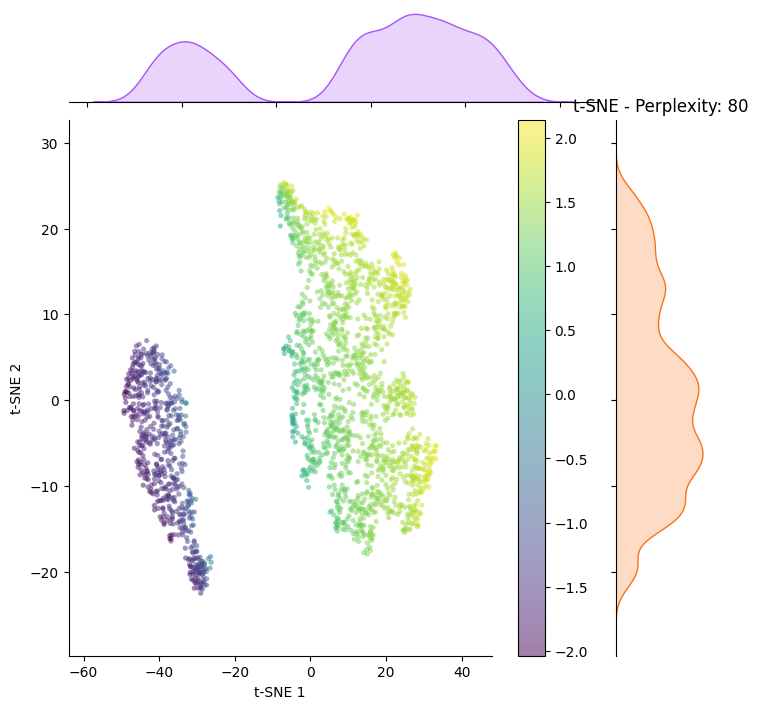

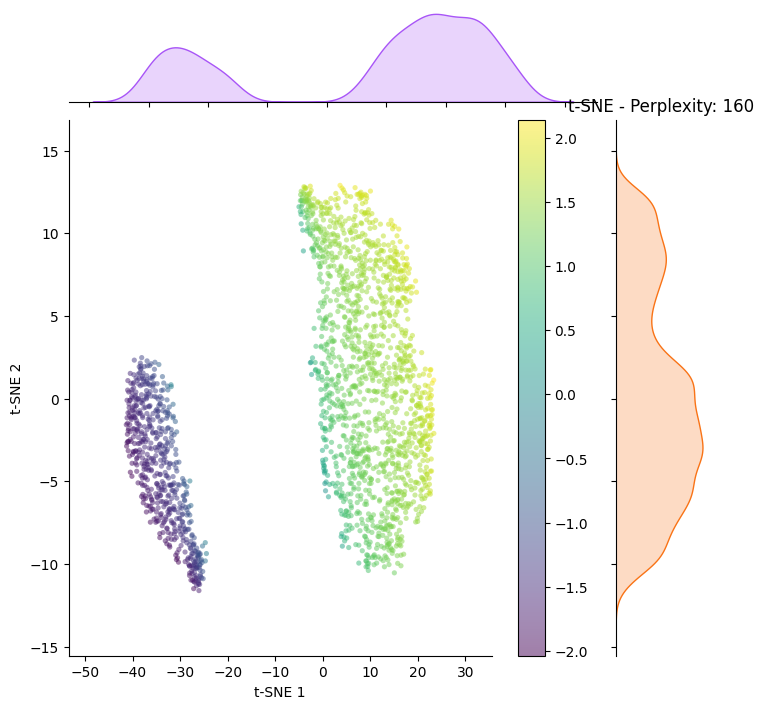

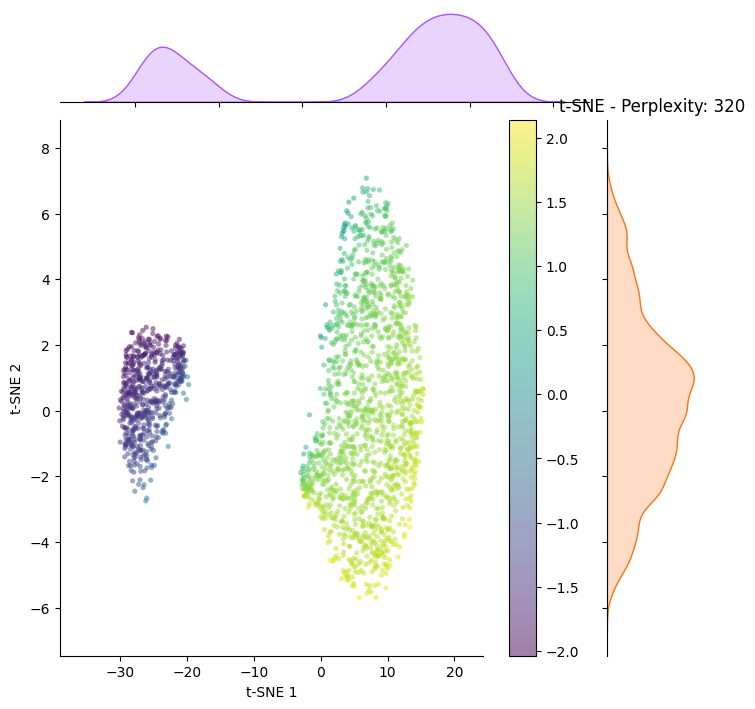

In [23]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

perplexities = [80, 160, 320]

for perplexity in perplexities:
  tsne = TSNE(perplexity=perplexity)
  emb = tsne.fit_transform(XY)

  x = emb[:,0]
  y = emb[:,1]

  g = sns.JointGrid(height=7, ratio=5)
  ax_scatter, ax_top, ax_right = g.ax_joint, g.ax_marg_x, g.ax_marg_y
  sc = ax_scatter.scatter(x, y, c=data['y'], s=14, alpha=0.5, linewidths=0)
  ax_scatter.set_xlabel("t-SNE 1")
  ax_scatter.set_ylabel("t-SNE 2")
  g.fig.colorbar(sc, ax=ax_scatter)
  sns.kdeplot(x=x, ax=ax_top, fill=True, color="#a855f7", bw_adjust=0.6)
  sns.kdeplot(y=y, ax=ax_right, fill=True, color="#f97316", bw_adjust=0.6)
  plt.title(f"t-SNE - Perplexity: {perplexity}")
  plt.show()


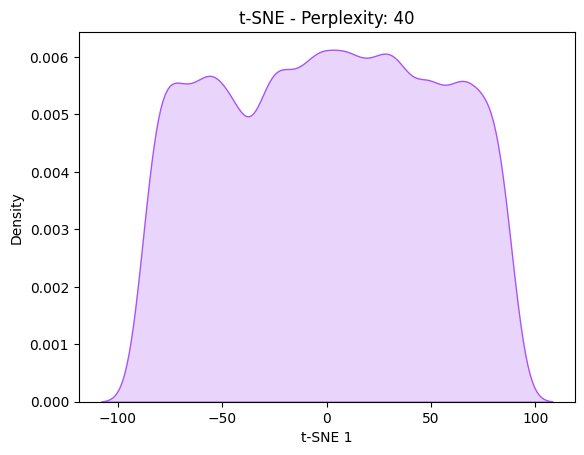

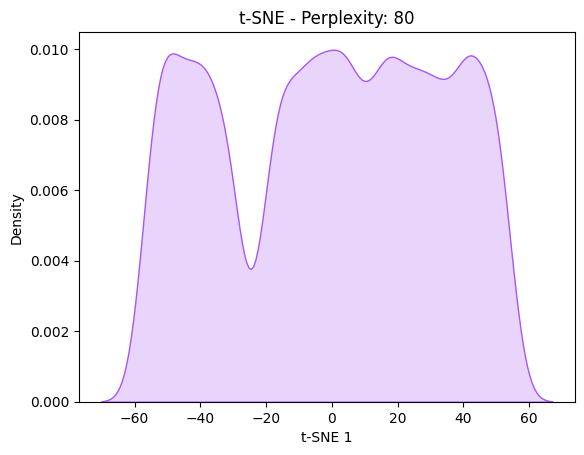

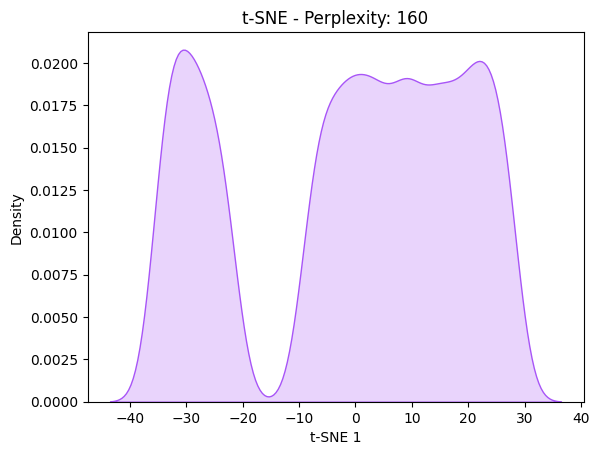

In [24]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

perplexities = [40, 80, 160]

for perplexity in perplexities:
  tsne = TSNE(n_components=1, perplexity=perplexity)
  emb = tsne.fit_transform(XY)

  x = emb[:,0]

  sns.kdeplot(x=x, fill=True, color="#a855f7", bw_adjust=0.6)
  plt.xlabel("t-SNE 1")
  plt.ylabel("Density")
  plt.title(f"t-SNE - Perplexity: {perplexity}")
  plt.show()


In [25]:
data = pd.read_csv("MuellerBrown_T-3_TimeSeries_run-1.data", header=None, names=['time', 'x', 'y'], sep='\\s+', comment="#")

# only take every N-th value
stride = 10
data = data.iloc[::stride]
# this is to reset the index
data.reset_index(drop=True, inplace=True)

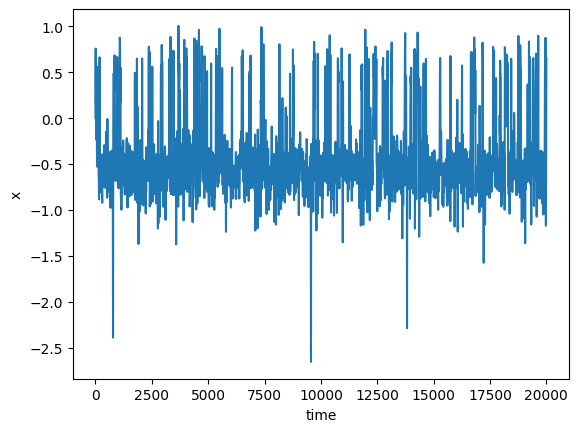

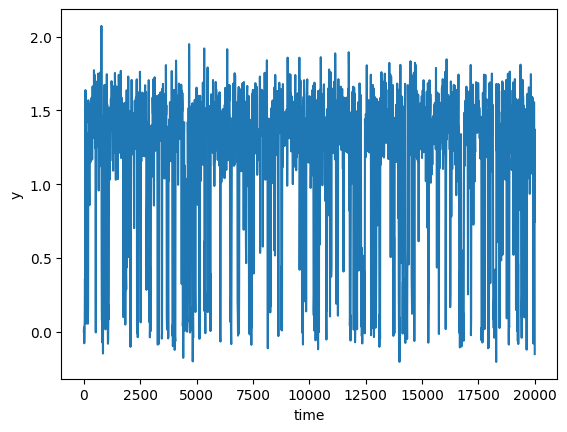

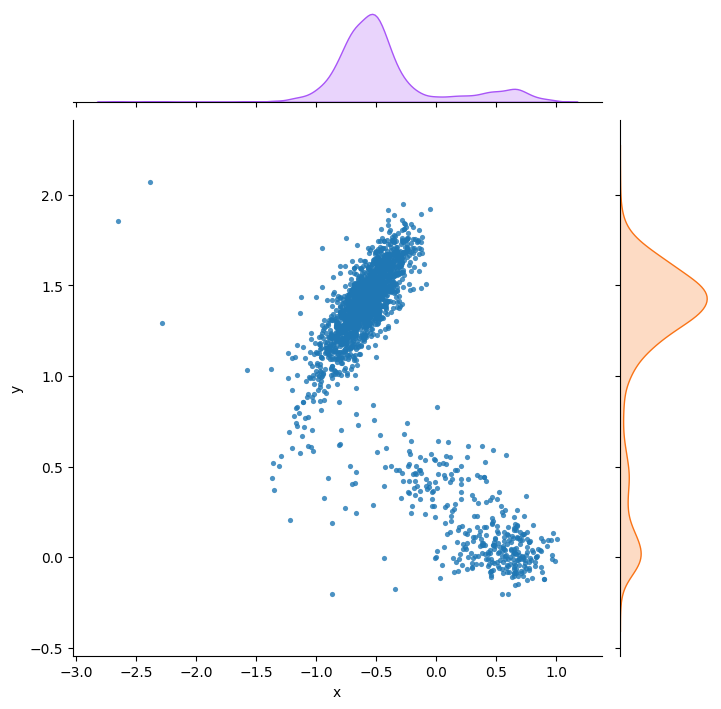

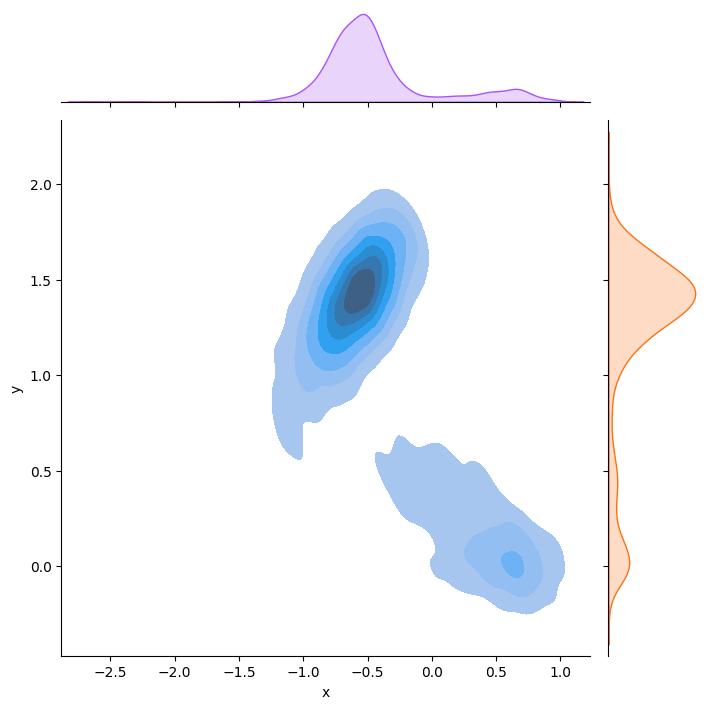

In [26]:
t=data['time']
x=data['x']
y=data['y']

plt.plot(t, x, label='x')
plt.xlabel('time')
plt.ylabel('x')
plt.show()

plt.plot(t, y, label='y')
plt.xlabel('time')
plt.ylabel('y')
plt.show()

g = sns.JointGrid(height=7, ratio=5)
ax_scatter, ax_top, ax_right = g.ax_joint, g.ax_marg_x, g.ax_marg_y
sc = ax_scatter.scatter(x, y, s=14, alpha=0.8, linewidths=0)
ax_scatter.set_xlabel("x")
ax_scatter.set_ylabel("y")
sns.kdeplot(x=x, ax=ax_top, fill=True, color="#a855f7", bw_adjust=0.6)
sns.kdeplot(y=y, ax=ax_right, fill=True, color="#f97316", bw_adjust=0.6)
plt.show()

g = sns.JointGrid(height=7, ratio=5)
ax_joint, ax_top, ax_right = g.ax_joint, g.ax_marg_x, g.ax_marg_y
sns.kdeplot(x=x, y=y,
            ax=ax_joint,
            bw_adjust=0.6,
            fill=True,
            levels=8)
ax_joint.set_xlabel("x")
ax_joint.set_ylabel("y")
sns.kdeplot(x=x, ax=ax_top, fill=True, color="#a855f7", bw_adjust=0.6)
sns.kdeplot(y=y, ax=ax_right, fill=True, color="#f97316", bw_adjust=0.6)
plt.show()



In [27]:
from sklearn.decomposition import PCA

XY = data[['x','y']]

# Apply PCA to 2D features
pca = PCA()
pca.fit(XY)

print("Explained variance ratio for 2D features:")
display(pca.explained_variance_ratio_)
print("Cumulative explained variance for 2D features:")
display(pca.explained_variance_ratio_.cumsum())

Explained variance ratio for 2D features:


array([0.83891987, 0.16108013])

Cumulative explained variance for 2D features:


array([0.83891987, 1.        ])

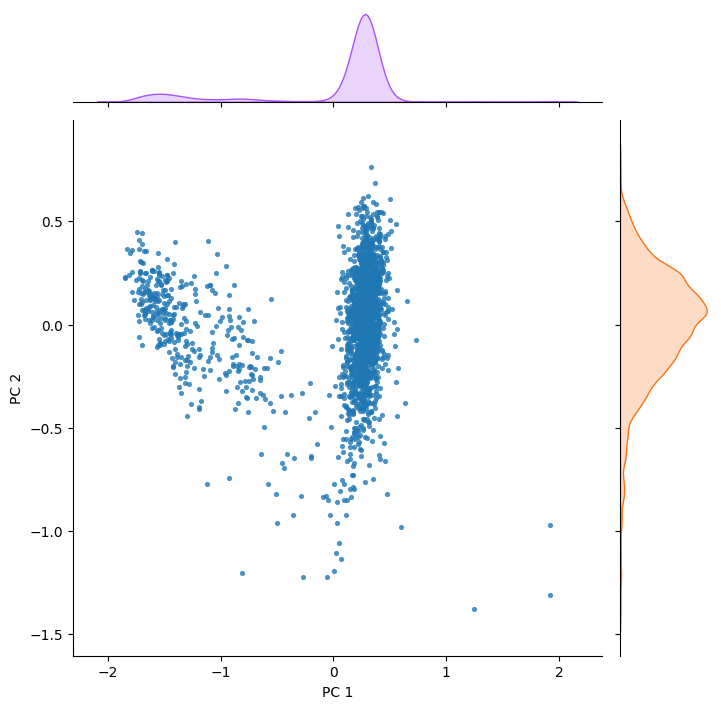

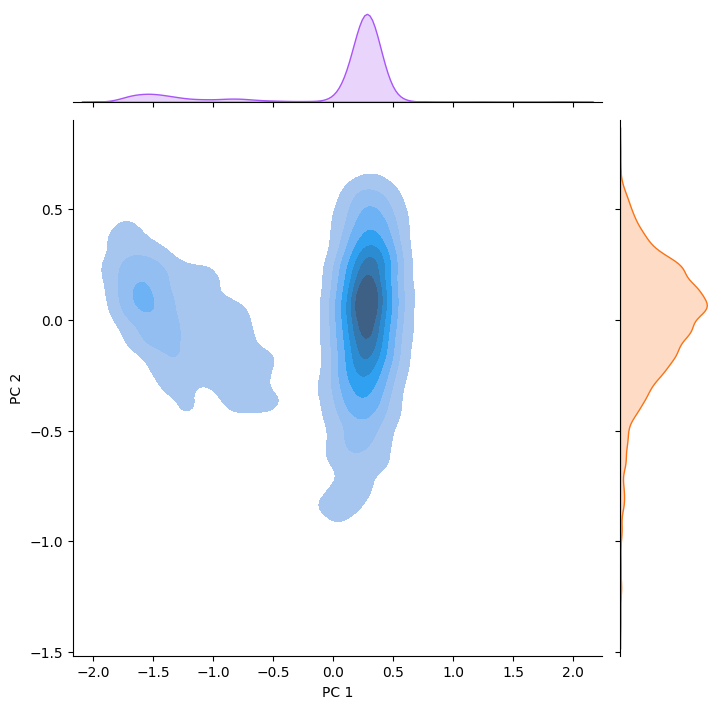

In [28]:
XY_pca = pca.transform(XY)
x=XY_pca[:,0]
y=XY_pca[:,1]

g = sns.JointGrid(height=7, ratio=5)
ax_scatter, ax_top, ax_right = g.ax_joint, g.ax_marg_x, g.ax_marg_y
sc = ax_scatter.scatter(x, y, s=14, alpha=0.8, linewidths=0)
ax_scatter.set_xlabel("PC 1")
ax_scatter.set_ylabel("PC 2")
sns.kdeplot(x=x, ax=ax_top, fill=True, color="#a855f7", bw_adjust=0.6)
sns.kdeplot(y=y, ax=ax_right, fill=True, color="#f97316", bw_adjust=0.6)
plt.show()

g = sns.JointGrid(height=7, ratio=5)
ax_joint, ax_top, ax_right = g.ax_joint, g.ax_marg_x, g.ax_marg_y
sns.kdeplot(x=x, y=y,
            ax=ax_joint,
            bw_adjust=0.6,
            fill=True,
            levels=8)
ax_joint.set_xlabel("PC 1")
ax_joint.set_ylabel("PC 2")
sns.kdeplot(x=x, ax=ax_top, fill=True, color="#a855f7", bw_adjust=0.6)
sns.kdeplot(y=y, ax=ax_right, fill=True, color="#f97316", bw_adjust=0.6)
plt.show()


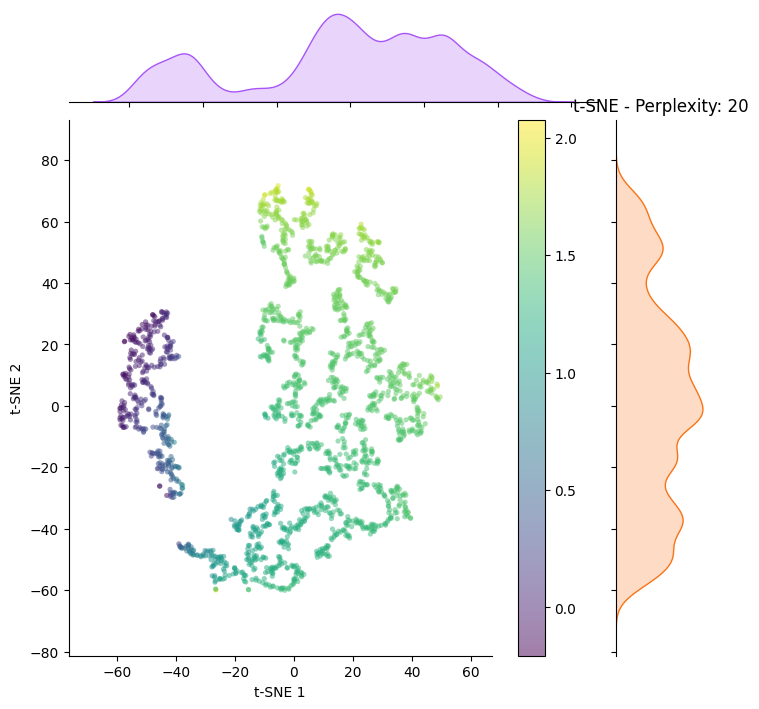

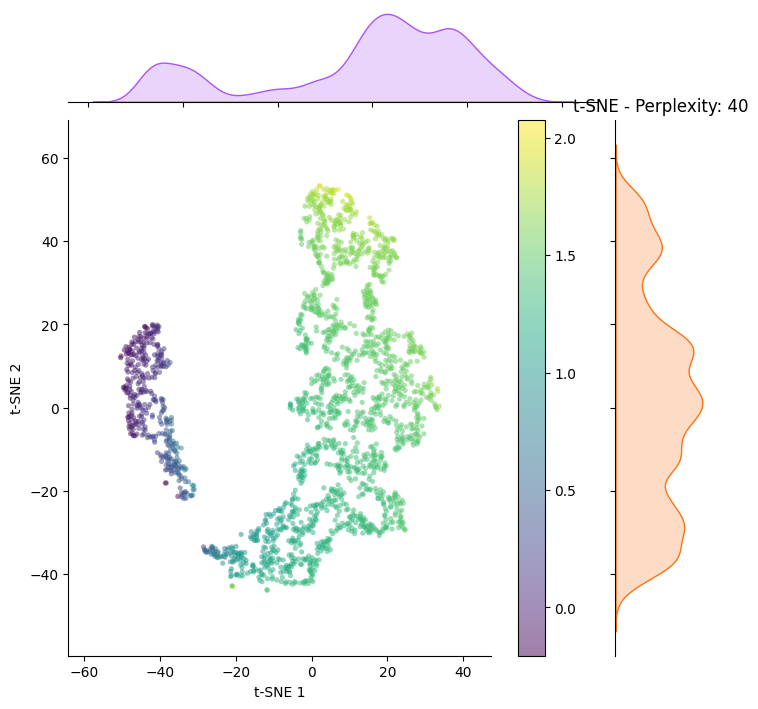

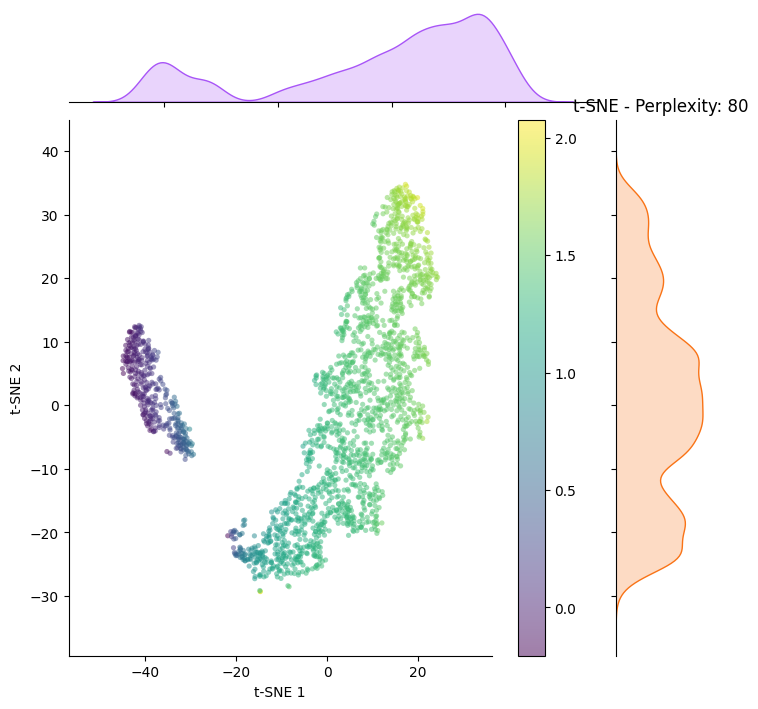

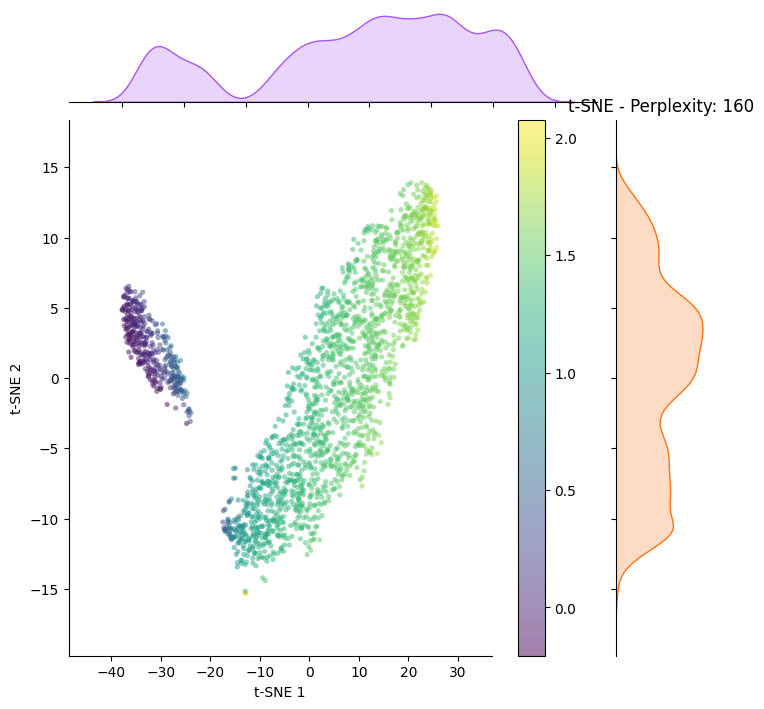

In [29]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

perplexities = [20, 40, 80, 160]

for perplexity in perplexities:
  tsne = TSNE(perplexity=perplexity)
  emb = tsne.fit_transform(XY)

  x = emb[:,0]
  y = emb[:,1]

  g = sns.JointGrid(height=7, ratio=5)
  ax_scatter, ax_top, ax_right = g.ax_joint, g.ax_marg_x, g.ax_marg_y
  sc = ax_scatter.scatter(x, y, c=data['y'], s=14, alpha=0.5, linewidths=0)
  ax_scatter.set_xlabel("t-SNE 1")
  ax_scatter.set_ylabel("t-SNE 2")
  g.fig.colorbar(sc, ax=ax_scatter)
  sns.kdeplot(x=x, ax=ax_top, fill=True, color="#a855f7", bw_adjust=0.6)
  sns.kdeplot(y=y, ax=ax_right, fill=True, color="#f97316", bw_adjust=0.6)
  plt.title(f"t-SNE - Perplexity: {perplexity}")
  plt.show()


### Alanine Dipeptide

In [ ]:
%%bash

datasets="
AlanineDipeptide_T-416K_Dihedrals.data
AlanineDipeptide_T-416K_HeavyAtomDistances.data
AlanineDipeptide_T-576K_Dihedrals.data
AlanineDipeptide_T-576K_HeavyAtomDistances.data
"

url="https://raw.githubusercontent.com/valsson-group/UNT-ChemicalApplicationsOfMachineLearning-Spring2026/refs/heads/main/Lecture-15_March-19-2026/Datasets"

for d in ${datasets}
do
  wget ${url}/${d} &> /dev/null
done

ls